In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

sys.path.append(os.path.abspath(".."))
from src.utils import apply_heavy_tailed_init, set_seed
from src.architectures import GeneralMLP
from src.continual_learning import update_SparseGPM_bases, apply_SparseGPM_projection, update_HTGPM_bases

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. GPU-Accelerated Data Loading ---
def get_gpu_mnist():
    """Loads full MNIST to GPU memory once."""
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('../data', train=False, download=True, transform=transform)

    # Push everything to DEVICE immediately
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - 0.1307) / 0.3081
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - 0.1307) / 0.3081
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()

def get_gpu_fashion_mnist():
    """Loads full Fashion-MNIST to GPU memory once."""
    # Official Fashion-MNIST mean and std for normalization
    mean, std = 0.2860, 0.3530

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])
    train_set = datasets.FashionMNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.FashionMNIST('../data', train=False, download=True, transform=transform)

    # Push to GPU and normalize manually to match your MNIST pipeline
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - mean) / std
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - mean) / std
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

# To switch tasks, simply toggle the comment on these lines:
# (train_x, train_y), (test_x, test_y) = get_gpu_fashion_mnist()

def get_task_data(x, y, digits):
    mask = torch.stack([y == d for d in digits]).sum(0).bool()
    return x[mask], y[mask]

# --- 2. Model & Ebbinghaus Logic ---
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400, bias=False),
            nn.Tanh(),
            nn.Linear(400, 400, bias=False),
            nn.Tanh(),
            nn.Linear(400, 10, bias=False)
        )

    def forward(self, x):
        return self.fc(x)

    def get_pre_activations(self, x):
        """Intercepts pre-activation state data matching layer keys explicitly."""
        pre_acts = {}

        # Layer 1
        x = self.fc[0](x)
        x = self.fc[1](x)
        pre_acts['fc1'] = x.clone()

        # Layer 2
        x = self.fc[2](x)
        x = self.fc[3](x)
        pre_acts['fc2'] = x.clone()

        # Layer 3
        x = self.fc[4](x)
        x = self.fc[5](x)
        pre_acts['fc3'] = x.clone()

        return pre_acts

    def get_layer_weights(self):
        """Returns linear transformation weight tensors mapped explicitly to activation keys."""
        return {
            'fc1': self.fc[1].weight,
            'fc2': self.fc[3].weight,
            'fc3': self.fc[5].weight
        }

# --- 3. Eval Function for BWT/FWT ---
def evaluate(model, tasks_data):
    model.eval()
    accs = []
    with torch.no_grad():
        for tx, ty in tasks_data:
            out = model(tx)
            acc = (out.argmax(1) == ty).float().mean().item()
            accs.append(acc)
    model.train()
    return accs

def check_gradient_direction(linear_layers, feature_list):
    """
    Measures gradient geometry across past task subspaces.
    Extracts directional alignment (parallel) and vector magnitudes (parallel vs orthogonal)
    normalized to total gradient energy for 2D Cartesian phase portraits.
    """
    if feature_list is None:
        return None

    layer_stats = {}
    with torch.no_grad():
        for i, layer in enumerate(linear_layers):
            if i >= len(feature_list) or feature_list[i] is None or layer.weight.grad is None:
                continue

            grad = layer.weight.grad          # Shape: (Out, In)
            basis = feature_list[i]         # Shape: (In, K)

            # --- 1. COMPUTE TOTAL GRADIENT METRICS ---
            total_norm = torch.linalg.norm(grad).item()
            if total_norm == 0:
                layer_stats[f'layer_{i}'] = {
                    'net_alignment': 0.0, 'pos_energy': 0.0, 'neg_energy': 0.0,
                    'total_norm': 0.0, 'parallel_norm': 0.0, 'orthogonal_norm': 0.0,
                    'x_parallel_normalized': 0.0, 'y_orthogonal_normalized': 0.0
                }
                continue

            # --- RE-ENGINEERED TRUE SUBSPACE ALIGNMENT ---
            # Isolate the parallel gradient vector component
            parallel_grad = torch.mm(torch.mm(grad, basis), basis.t())
            orthogonal_grad = grad - parallel_grad
            parallel_norm = torch.linalg.norm(parallel_grad).item()
            orthogonal_norm = torch.linalg.norm(orthogonal_grad).item()

            if parallel_norm > 0:
                # 1. Project the current weights into the exact same past task subspace
                parallel_weight = torch.mm(torch.mm(layer.weight, basis), basis.t())

                # 2. Compute the true Frobenius inner product (Matrix Dot Product)
                # This measures if the update vector points WITH or AGAINST the existing weight vector
                # Formula: trace(A.T @ B)
                dot_product = torch.sum(parallel_grad * parallel_weight).item()

                # 3. Normalize the score by the magnitudes to get a true Cosine Similarity (-1 to +1)
                weight_norm = torch.linalg.norm(parallel_weight).item()
                if weight_norm > 0:
                    true_alignment = dot_product / (parallel_norm * weight_norm)
                else:
                    true_alignment = 0.0
            else:
                true_alignment = 0.0

            # --- MAP TO CLEAN VISUAL COORDINATES ---
            # X: The true cosine direction of the update multiplied by its energy share
            x_coord = true_alignment * (parallel_norm / total_norm)

            # Y: The pure orthogonal exploration volume share
            y_coord = orthogonal_norm / total_norm

            layer_stats[f'layer_{i}'] = {
                # Directional Signs (Legacy tracking for time overlay)
                'net_alignment': true_alignment,

                # Raw Vector Metrics (Energy Magnitudes)
                'total_norm': total_norm,
                'parallel_norm': parallel_norm,
                'orthogonal_norm': orthogonal_norm,

                # Phase Portrait Coordinates (Unit Bound)
                'x_parallel_normalized': x_coord,      # Range: -1.0 to +1.0
                'y_orthogonal_normalized': y_coord      # Range:  0.0 to +1.0
            }

    return layer_stats

# --- New Configuration ---
EVAL_EVERY_N_BATCHES = 50

class CLMetricsTracker:
    def __init__(self, max_tasks=20):
        self.max_tasks = max_tasks

        # Core structured history
        self.history = {
            'step': [],
            'current_task_loss': [],
        }

        # Dynamically allocate separate tracking lists per individual task trajectory
        # This keeps columns isolated and ready for flat CSV extraction
        for t_idx in range(max_tasks):
            self.history[f'task_{t_idx}_acc'] = []

    def log(self, step, acc_list, loss):
        """
        Logs a single training step's snapshot.

        Args:
            step: The global training step index.
            acc_list: A list of current validation accuracies, e.g., [acc_t0, acc_t1, ...]
            loss: Float scalar value of the active task's training loss.
        """
        self.history['step'].append(step)
        self.history['current_task_loss'].append(float(loss))

        # Append accuracy scores for tasks seen so far
        for t_idx in range(self.max_tasks):
            col_key = f'task_{t_idx}_acc'

            if t_idx < len(acc_list):
                # Ensure we store standard Python floats
                self.history[col_key].append(float(acc_list[t_idx]))
            else:
                # Pad out future tasks that haven't been introduced yet with None
                self.history[col_key].append(None)

    def save_to_csv(self, filepath="cl_experiment_metrics.csv"):
        """
        Flattens the gathered execution trajectories and exports them into a clean,
        tabular CSV file ready for immediate pandas / seaborn plotting.
        """
        # Ensure target directory structures exist
        directory = os.path.dirname(filepath)
        if directory and not os.path.exists(directory):
            os.makedirs(directory)

        # 1. Dynamically gather column header keys based on execution structure
        # We start with the base tracking metrics
        headers = ['step', 'current_task_loss']

        # Append only the task accuracy columns that actually contains data to avoid empty columns
        active_task_cols = []
        for t_idx in range(self.max_tasks):
            col_key = f'task_{t_idx}_acc'
            # Check if at least one evaluation step captured a real value for this task
            if any(val is not None for val in self.history[col_key]):
                active_task_cols.append(col_key)

        headers.extend(active_task_cols)
        num_rows = len(self.history['step'])

        # 2. Open file stream and write row-by-row
        with open(filepath, mode='w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)

            # Write column header row
            writer.writerow(headers)

            # Write tabular data rows
            for r_idx in range(num_rows):
                row_data = []
                for header in headers:
                    val = self.history[header][r_idx]
                    # Format None entries as empty string cells for Excel/Pandas handling
                    row_data.append("" if val is None else val)
                writer.writerow(row_data)

        print(f"Tabular execution profiles successfully saved to: '{filepath}'")

class AlignmentTracker:
    def __init__(self, num_tasks=5):
        self.steps = []
        self.task_boundaries = []

        # Core metric histories organized by layer keys (e.g., 'layer_0', 'layer_1')
        self.net_alignments = {}
        self.total_norm = {}
        self.parallel_norm = {}
        self.orthogonal_norm = {}
        self.x_parallel_normalized = {}
        self.y_orthogonal_normalized = {}

        # Track accuracy histories as separate step-aligned lists
        self.num_tasks = num_tasks
        self.accuracies = {f'task_{i}': [] for i in range(num_tasks)}
        self.acc_steps = []  # Timeline tracking for evaluation steps

    def log_gradients(self, step, stats):
        """
        Accepts the full stats dictionary across all calculated layers
        and appends metrics into layer-specific tracking arrays dynamically.
        """
        if not stats:
            return

        self.steps.append(step)

        for layer_key, layer_metrics in stats.items():
            # Dynamically initialize sub-lists for newly encountered layer names
            if layer_key not in self.net_alignments:
                self.net_alignments[layer_key] = []
                self.total_norm[layer_key] = []
                self.parallel_norm[layer_key] = []
                self.orthogonal_norm[layer_key] = []
                self.x_parallel_normalized[layer_key] = []
                self.y_orthogonal_normalized[layer_key] = []

            # Append metrics to the active layer profile
            self.net_alignments[layer_key].append(layer_metrics['net_alignment'])
            self.total_norm[layer_key].append(layer_metrics['total_norm'])
            self.parallel_norm[layer_key].append(layer_metrics['parallel_norm'])
            self.orthogonal_norm[layer_key].append(layer_metrics['orthogonal_norm'])
            self.x_parallel_normalized[layer_key].append(layer_metrics['x_parallel_normalized'])
            self.y_orthogonal_normalized[layer_key].append(layer_metrics['y_orthogonal_normalized'])

    def log_accuracies(self, step, acc_list):
        self.acc_steps.append(step)
        for i, acc in enumerate(acc_list):
            if i < self.num_tasks:
                self.accuracies[f'task_{i}'].append(acc)

In [ ]:
import torch
import torch.nn as nn

# --- 1. GLOBAL EXPERIMENT HYPERPARAMETERS ---
RUN_SEEDS = [0]  # Define your background sweep parameters here
NUM_TASKS = 20                 # Long horizon task stream
EPOCHS_PER_TASK = 10           # 5 epochs per task to accelerate crossing discovery
LR = 5e-3
BATCH_SIZE = 256
CALIB_SAMPLE_SIZE = 256        # Size of evaluation batch to extract the spectrum

# Structural variables matching your target deep architecture
hidden_size = 784
depth = 9
activation_name = "tanh"
bias = False

# Algorithm Configuration
GLOBAL_THRESHOLD = 0.97        # Threshold for subspace energy retention
ALPHA = 2.0                    # Set alpha=2.0 for Gaussian comparison, <2.0 for Heavy-Tailed Init

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EVAL_EVERY_N_BATCHES = 200

# --- 2. OPTIMIZED DATA LOADING ---
def get_gpu_data(dataset):
    """Loads raw tensors to GPU once to avoid repetitive overhead."""
    imgs = torch.stack([img for img, _ in dataset]).to(DEVICE).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(DEVICE)
    return imgs, lbls

print(f"Initializing VRAM memory pinning pipeline on device: {DEVICE}")
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST('../data', train=False, download=True, transform=transforms.ToTensor())

train_imgs, train_lbls = get_gpu_data(mnist_train)
test_imgs_raw, test_lbls = get_gpu_data(mnist_test)

def generate_permutations(num_tasks, num_pixels=784, seed=42):
    """Generates clean pseudorandom domain permutations mapping each task stream."""
    rng = np.random.RandomState(seed)
    perms = [torch.arange(num_pixels).to(DEVICE)]  # Task 0 is standard un-permuted MNIST
    for _ in range(num_tasks - 1):
        perms.append(torch.from_numpy(rng.permutation(num_pixels)).to(DEVICE))
    return perms


# --- 3. CORE BACKGROUND SWEEP PIPELINE ---
for current_seed in RUN_SEEDS:
    print("\n" + "="*80)
    print(f"LAUNCHING PARAMETER SWEEP FOR RANDOM EXPERIMENTAL SEED [s={current_seed}]")
    print("="*80)

    # Synchronize random seeds across software frameworks
    set_seed(current_seed)

    # Generate unique sequence mappings matching this seed's stream definition
    task_permutations = generate_permutations(num_tasks=NUM_TASKS, seed=current_seed)

    # Initialize Fresh Neural Network Architecture & Target Optimization Parameters
    model = GeneralMLP(784, hidden_size, 10, depth, activation_name, bias=bias).to(DEVICE)
    model = apply_heavy_tailed_init(model=model, alpha=ALPHA, g=1.0, seed=current_seed)

    optimizer = optim.SGD(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    tracker = CLMetricsTracker(max_tasks=NUM_TASKS)

    # Automatically map sequential layer keys from your module configurations
    with torch.no_grad():
        dummy_x = torch.randn(5, 784, device=DEVICE)
        sample_reps = model.get_pre_activations(dummy_x)
        raw_keys = list(sample_reps.keys())
        hidden_keys = sorted([k for k in raw_keys if isinstance(k, int)])
        layer_keys = hidden_keys + [k for k in raw_keys if isinstance(k, str)]

    # Cash parameter references to modules in strict structural matrix order
    active_linear_layers = [module for module in model.modules() if isinstance(module, nn.Linear)]

    # Reset the persistent memory subspace registers
    sparse_gpm_features = [None] * len(layer_keys)
    total_steps = 0

    print(f"Architecture Depth: {depth} layers | Hidden Width: {hidden_size} neurons")
    print(f"Alpha Initializer Profile: {ALPHA} | Global Target Energy Threshold: {GLOBAL_THRESHOLD * 100:.1f}%")
    print("-"*80)

    # --- 4. MAIN CONTINUAL LEARNING STREAM ---
    for t_idx in range(NUM_TASKS):
        current_perm = task_permutations[t_idx]

        # Splice task domain images instantly via parallel VRAM index slicing
        tx = train_imgs[:, current_perm]
        ty = train_lbls

        print(f"\n--- Task {t_idx:02d}/{NUM_TASKS:02d} | Seed: {current_seed} ---")

        for epoch in range(EPOCHS_PER_TASK):
            model.train()
            indices = torch.randperm(len(tx))

            for i in range(0, len(tx), BATCH_SIZE):
                batch_idx = indices[i:i+BATCH_SIZE]
                bx, by = tx[batch_idx], ty[batch_idx]

                optimizer.zero_grad()

                output = model(bx)
                loss_current = criterion(output, by)
                loss_current.backward()

                # Step A: Geometric Sparse Subspace Projection Interception Step
                apply_SparseGPM_projection(
                    linear_layers=active_linear_layers,
                    feature_list=sparse_gpm_features,
                )

                # Step B: Commit clean weight step changes to parameter arrays
                optimizer.step()

                # Snapshot logging evaluation cycle across historical steps
                if total_steps % EVAL_EVERY_N_BATCHES == 0:
                    current_accs = []
                    model.eval()
                    with torch.no_grad():
                        for eval_t_idx in range(t_idx + 1):
                            eval_perm = task_permutations[eval_t_idx]
                            test_x = test_imgs_raw[:, eval_perm]

                            outputs = model(test_x[:1000])
                            preds = outputs.argmax(dim=1)
                            acc = (preds == test_lbls[:1000]).float().mean().item()
                            current_accs.append(acc)

                    tracker.log(step=total_steps, acc_list=current_accs, loss=loss_current.item())
                    acc_report = " | ".join([f"T{j}: {current_accs[j]*100:.1f}%" for j in range(t_idx + 1)])
                    print(f"Seed {current_seed} | Step {total_steps:04d} (Epoch {epoch}) -> {acc_report}")

                total_steps += 1

        # Post-Task Calibration Step: Update Subspace Representation Matrices
        calib_indices = torch.randperm(len(tx))[:CALIB_SAMPLE_SIZE]
        calib_images = tx[calib_indices]

        # Compute SVD and extract power-law components to synchronize structural features
        if ALPHA == 2.0:
            print("Applying Standard GPM Subspace Update (Gaussian Regime)")
            sparse_gpm_features, current_ranks = update_SparseGPM_bases(
                model=model,
                images=calib_images,
                global_threshold=GLOBAL_THRESHOLD,
                local_threshold=1.0,
                xi=0.0,
                feature_list=sparse_gpm_features,
                activation_fn=torch.tanh
            )
        else:
            print("Applying Heavy-Tailed GPM Subspace Update (Alpha < 2.0 Regime)")
            sparse_gpm_features, current_ranks = update_HTGPM_bases(
                model=model,
                images=calib_images,
                global_threshold=GLOBAL_THRESHOLD,
                alpha=ALPHA,
                feature_list=sparse_gpm_features,
                activation_fn=torch.tanh
            )
        print(f"Task {t_idx} complete. Subspace ranks synchronized.")

    # Save output dataset cleanly with a variable filename format
    if ALPHA < 2.0:
        output_filename = f"htgpm_alpha{ALPHA}_s{current_seed}.csv"
    else:
        output_filename = f"gpm_alpha{ALPHA}_s{current_seed}.csv"
    # tracker.save_to_csv(output_filename)
    print(f"Sweep for seed {current_seed} serialized successfully to {output_filename}.\n")

print("\n" + "="*80)
print("ALL MULTI-SEED PARAMETER CONVERSIONS COMPLETED IN BACKGROUND POOL.")
print("="*80)

Initializing VRAM memory pinning pipeline on device: cuda

LAUNCHING PARAMETER SWEEP FOR RANDOM EXPERIMENTAL SEED [s=0]
Applying HT Init: alpha=1.2, g=1.0, seed=0
Architecture Depth: 9 layers | Hidden Width: 784 neurons
Alpha Initializer Profile: 1.2 | Global Target Energy Threshold: 97.0%
--------------------------------------------------------------------------------

--- Task 00/20 | Seed: 0 ---
Seed 0 | Step 0000 (Epoch 0) -> T0: 22.4%
Seed 0 | Step 0200 (Epoch 0) -> T0: 91.2%
Seed 0 | Step 0400 (Epoch 1) -> T0: 93.4%
Seed 0 | Step 0600 (Epoch 2) -> T0: 94.5%
Seed 0 | Step 0800 (Epoch 3) -> T0: 95.1%
Seed 0 | Step 1000 (Epoch 4) -> T0: 95.2%
Seed 0 | Step 1200 (Epoch 5) -> T0: 95.5%
Seed 0 | Step 1400 (Epoch 5) -> T0: 95.9%
Seed 0 | Step 1600 (Epoch 6) -> T0: 96.2%
Seed 0 | Step 1800 (Epoch 7) -> T0: 95.9%
Seed 0 | Step 2000 (Epoch 8) -> T0: 96.5%
Seed 0 | Step 2200 (Epoch 9) -> T0: 96.8%
Applying Standard GPM Subspace Update (Gaussian Regime)
Task 0 complete. Subspace ranks synchr

<>:188: SyntaxWarning: invalid escape sequence '\m'
<>:188: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_101297/1930512270.py:188: SyntaxWarning: invalid escape sequence '\m'
  axs[1, 1].set_ylabel("Memory Decay Score ($\max R_{t,i} - R_{T,i}$)")


Evaluating Dense Baseline Horizon Performance...
Evaluating Sparse Heavy-Tail Horizon Performance...


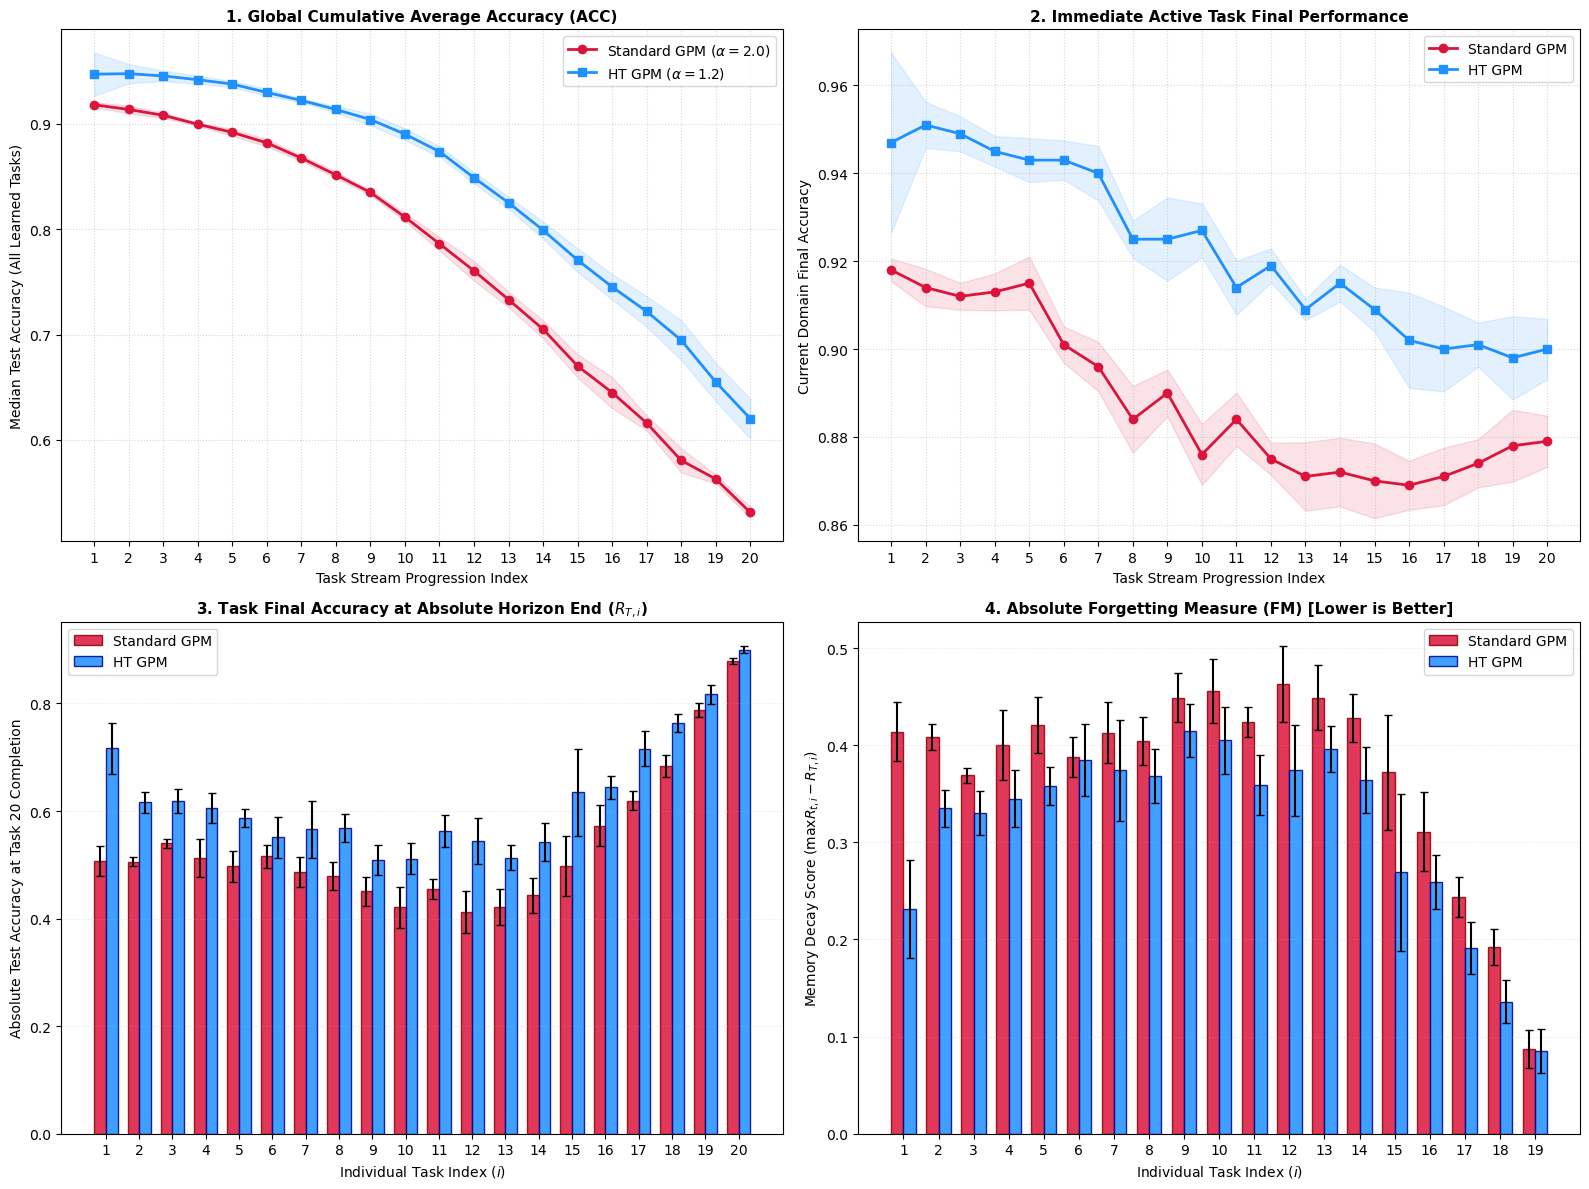

In [18]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. CONFIGURATION & SEED PARSING ---
SEEDS = [0, 1, 2, 42, 67]  # Your 5 active evaluation seeds
NUM_TASKS = 20

# Define paths matching your naming template dynamically
dense_files = [f"gpm_alpha2.0_s{seed}.csv" for seed in SEEDS]
sparse_files = [f"htgpm_alpha1.2_s{seed}.csv" for seed in SEEDS]


# --- 2. THE COMPREHENSIVE CL PIPELINE ---
def process_multi_seed_cl(file_list):
    """Processes multiple task logs, computing median and std across seeds for the full 2x2 framework."""
    all_final_accs = []
    all_current_task_accs = []
    all_horizon_end_accs = []
    all_forgetting_measures = []
    task_indices_axis = np.arange(1, NUM_TASKS + 1)

    for fpath in file_list:
        if not os.path.exists(fpath):
            print(f"Warning: File {fpath} missing, skipping from evaluation group.")
            continue

        df = pd.read_csv(fpath)
        num_entries = len(df)

        # Sort chronological task columns
        task_cols = [
            c
            for c in df.columns
            if c.startswith("task_") and c.endswith("_acc")
        ]
        task_cols = sorted(task_cols, key=lambda x: int(x.split('_')[1]))
        acc_matrix = df[task_cols].values

        # Track active task footprint to locate step transitions
        active_tasks_per_step = np.array(
            [df.iloc[idx][task_cols].notna().sum() for idx in range(num_entries)]
        )

        # Detect exact step indices where each task finishes training
        transition_indices = []
        current_num = active_tasks_per_step[0]
        for idx in range(1, num_entries):
            if active_tasks_per_step[idx] > current_num:
                transition_indices.append(idx - 1)
                current_num = active_tasks_per_step[idx]
        transition_indices.append(num_entries - 1)

        if len(transition_indices) != NUM_TASKS:
            print(
                f"Warning: Boundary mismatch in {fpath}. Detected {len(transition_indices)} instead of {NUM_TASKS}"
            )

        # Extract values strictly at the 20 transition points
        seed_final_accs = []
        seed_curr_task_accs = []

        for t_idx, boundary_idx in enumerate(transition_indices):
            # 1. Global Average Accuracy (ACC) history at task completion
            row = acc_matrix[boundary_idx, :]
            active_accs = row[~np.isnan(row)]
            seed_final_accs.append(
                np.mean(active_accs) if len(active_accs) > 0 else 0.0
            )

            # 2. Plasticity Snapshot: Accuracy on the specific active task at wrap-up
            seed_curr_task_accs.append(acc_matrix[boundary_idx, t_idx])

        # --- HORIZON COMPENSATED EVALUATION METRICS ---
        # Evaluate everything relative to the final row index (the absolute end of the stream)
        final_row_idx = transition_indices[-1]
        seed_horizon_accs = []
        seed_forgetting = []

        for t_idx in range(NUM_TASKS):
            # Final performance at the absolute end of the stream (Plot 3)
            final_acc = acc_matrix[final_row_idx, t_idx]
            seed_horizon_accs.append(final_acc if not np.isnan(final_acc) else 0.0)

            # Max performance reached at any stage of the stream
            task_history = acc_matrix[:, t_idx]
            valid_history = task_history[~np.isnan(task_history)]

            if len(valid_history) > 0:
                peak_acc = np.max(valid_history)
                # FM = Peak - Final (Plot 4)
                seed_forgetting.append(max(0.0, peak_acc - final_acc))
            else:
                seed_forgetting.append(0.0)

        all_final_accs.append(seed_final_accs)
        all_current_task_accs.append(seed_curr_task_accs)
        all_horizon_end_accs.append(seed_horizon_accs)
        all_forgetting_measures.append(seed_forgetting)

    # Convert to matrices [num_seeds, num_tasks]
    arr_final = np.array(all_final_accs)
    arr_curr = np.array(all_current_task_accs)
    arr_horiz = np.array(all_horizon_end_accs)
    arr_forget = np.array(all_forgetting_measures)

    # Compute statistics along the seed axis
    return (
        task_indices_axis,
        np.median(arr_final, axis=0), np.std(arr_final, axis=0),
        np.median(arr_curr, axis=0), np.std(arr_curr, axis=0),
        np.median(arr_horiz, axis=0), np.std(arr_horiz, axis=0),
        np.median(arr_forget, axis=0), np.std(arr_forget, axis=0)
    )


# --- 3. RUN METRIC EVALUATIONS ---
print("Evaluating Dense Baseline Horizon Performance...")
(
    tasks_x,
    d_med_acc, d_std_acc,
    d_med_curr, d_std_curr,
    d_med_horiz, d_std_horiz,
    d_med_forg, d_std_forg,
) = process_multi_seed_cl(dense_files)

print("Evaluating Sparse Heavy-Tail Horizon Performance...")
(
    _,
    s_med_acc, s_std_acc,
    s_med_curr, s_std_curr,
    s_med_horiz, s_std_horiz,
    s_med_forg, s_std_forg,
) = process_multi_seed_cl(sparse_files)


# --- 4. 2x2 MIXED PLOT VISUALIZATION (LINE + COLUMN GRID) ---
fig, axs = plt.subplots(2, 2, figsize=(16, 12), dpi=100)
tasks_axis = np.arange(1, len(tasks_x) + 1)
bar_width = 0.35  # Controls column tightness

# --- [TOP LEFT] PLOT 1: Cumulative Average Accuracy (ACC) [Line/Timeline] ---
axs[0, 0].plot(tasks_axis, d_med_acc, color="crimson", marker="o", linewidth=2, label="Standard GPM ($\\alpha=2.0$)")
axs[0, 0].fill_between(tasks_axis, d_med_acc - d_std_acc, d_med_acc + d_std_acc, color="crimson", alpha=0.12)
axs[0, 0].plot(tasks_axis, s_med_acc, color="dodgerblue", marker="s", linewidth=2, label="HT GPM ($\\alpha=1.2$)")
axs[0, 0].fill_between(tasks_axis, s_med_acc - s_std_acc, s_med_acc + s_std_acc, color="dodgerblue", alpha=0.12)
axs[0, 0].set_title("1. Global Cumulative Average Accuracy (ACC)", fontsize=11, weight='bold')
axs[0, 0].set_xlabel("Task Stream Progression Index")
axs[0, 0].set_ylabel("Median Test Accuracy (All Learned Tasks)")
axs[0, 0].set_xticks(tasks_axis)
axs[0, 0].grid(True, linestyle=":", alpha=0.5)
axs[0, 0].legend()

# --- [TOP RIGHT] PLOT 2: Target Task Performance [Line/Timeline] ---
axs[0, 1].plot(tasks_axis, d_med_curr, color="crimson", marker="o", linewidth=2, label="Standard GPM")
axs[0, 1].fill_between(tasks_axis, d_med_curr - d_std_curr, d_med_curr + d_std_curr, color="crimson", alpha=0.12)
axs[0, 1].plot(tasks_axis, s_med_curr, color="dodgerblue", marker="s", linewidth=2, label="HT GPM")
axs[0, 1].fill_between(tasks_axis, s_med_curr - s_std_curr, s_med_curr + s_std_curr, color="dodgerblue", alpha=0.12)
axs[0, 1].set_title("2. Immediate Active Task Final Performance", fontsize=11, weight='bold')
axs[0, 1].set_xlabel("Task Stream Progression Index")
axs[0, 1].set_ylabel("Current Domain Final Accuracy")
axs[0, 1].set_xticks(tasks_axis)
axs[0, 1].grid(True, linestyle=":", alpha=0.5)
axs[0, 1].legend()

# --- [BOTTOM LEFT] PLOT 3: Absolute Final Accuracy at Stream End [Grouped Column] ---
axs[1, 0].bar(tasks_axis - bar_width/2, d_med_horiz, yerr=d_std_horiz, width=bar_width,
              color="crimson", alpha=0.85, edgecolor='darkred', capsize=3, label="Standard GPM")
axs[1, 0].bar(tasks_axis + bar_width/2, s_med_horiz, yerr=s_std_horiz, width=bar_width,
              color="dodgerblue", alpha=0.85, edgecolor='darkblue', capsize=3, label="HT GPM")
axs[1, 0].set_title("3. Task Final Accuracy at Absolute Horizon End ($R_{T, i}$)", fontsize=11, weight='bold')
axs[1, 0].set_xlabel("Individual Task Index ($i$)")
axs[1, 0].set_ylabel("Absolute Test Accuracy at Task 20 Completion")
axs[1, 0].set_xticks(tasks_axis)
axs[1, 0].grid(True, linestyle=":", alpha=0.3, axis='y')
axs[1, 0].legend()

# --- [BOTTOM RIGHT] PLOT 4: Absolute Forgetting Measure (FM) [Grouped Column] ---
# Truncating at Task 19 since Task 20 cannot experience retroactive forgetting yet
tasks_axis_fm = tasks_axis[:-1]
axs[1, 1].bar(tasks_axis_fm - bar_width/2, d_med_forg[:-1], yerr=d_std_forg[:-1], width=bar_width,
              color="crimson", alpha=0.85, edgecolor='darkred', capsize=3, label="Standard GPM")
axs[1, 1].bar(tasks_axis_fm + bar_width/2, s_med_forg[:-1], yerr=s_std_forg[:-1], width=bar_width,
              color="dodgerblue", alpha=0.85, edgecolor='darkblue', capsize=3, label="HT GPM")
axs[1, 1].set_title("4. Absolute Forgetting Measure (FM) [Lower is Better]", fontsize=11, weight='bold')
axs[1, 1].set_xlabel("Individual Task Index ($i$)")
axs[1, 1].set_ylabel("Memory Decay Score ($\max R_{t,i} - R_{T,i}$)")
axs[1, 1].set_xticks(tasks_axis_fm)
axs[1, 1].grid(True, linestyle=":", alpha=0.3, axis='y')
axs[1, 1].legend()

# --- 5. CLEANUP & EXPORT ---
# plt.suptitle(
#     "Continual Learning Comprehensive Matrix Breakdown\n(5 Randomized Seeds / Median $\\pm$ Std)",
#     fontsize=14,
#     weight="bold",
#     y=0.96,
# )
plt.tight_layout()
plt.savefig("gpm_comprehensive_2x2_summary.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TASKS = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
LR = 1e-2
GAMMA = 0.001
K_STEEPNESS = 3000.0
BATCH_SIZE = 64 # Increased for GPU efficiency
EPOCHS_PER_TASK = 10

class EbbinghausOptimizer:
    def __init__(self, model, lr=LR, gamma=GAMMA, k_max=K_STEEPNESS, k_min=10):
        self.params = [p for p in model.parameters() if p.requires_grad]
        self.lr = lr
        self.gamma = gamma
        self.k_max = k_max
        self.k_min = k_min
        self.k_layers = []
        for i in range(len(self.params)):
            # Linear example:
            ratio = i / (len(self.params) - 1)
            k_val = self.k_max - ratio * (self.k_max - self.k_min)
            self.k_layers.append(k_val)
        # Stability accumulator S_i
        self.stability = [torch.zeros_like(p, device=DEVICE) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue

                # 1. Dynamic Decay (Standard)
                # We can stick to a simpler decay here since the growth is self-regulating
                self.stability[i] = (1.0 - self.gamma) * self.stability[i]

                # 2. Saturating Growth (Diminishing Returns)
                # The 'fuller' the memory, the harder it is to add more.
                grad_sq = p.grad ** 2
                growth_resistance = 1.0 + self.stability[i]
                self.stability[i] += grad_sq / growth_resistance

                # 3. Calculate Hyperbolic Plasticity Filter
                plasticity = 1.0 / (1.0 + self.k_layers[i] * self.stability[i])

                # 4. Apply Filtered Update
                p.data -= self.lr * plasticity * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()

# --- 2. Training Loop ---
model = SimpleMLP().to(DEVICE)
ebbinghaus_opt = EbbinghausOptimizer(model)
criterion = nn.CrossEntropyLoss()
tracker = MetricsTracker()
total_steps = 0

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
all_test_tasks = [get_task_data(test_x, test_y, t) for t in TASKS]
results_matrix = []

for t_idx, digits in enumerate(TASKS):
    tx, ty = get_task_data(train_x, train_y, digits)
    print(f"Training Task {t_idx} (Digits {digits})")

    for epoch in range(EPOCHS_PER_TASK):
        indices = torch.randperm(len(tx))
        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            ebbinghaus_opt.zero_grad()
            output = model(bx)
            loss = criterion(output, by)
            loss.backward()

            # This is where the magic happens: No penalty, just a filtered step
            ebbinghaus_opt.step()

            total_steps += 1

            # High-Resolution Intra-Task Tracking
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                current_accs = evaluate(model, all_test_tasks)
                tracker.log(total_steps, current_accs, loss.item(), ebbinghaus_opt.stability)

        current_accs = evaluate(model, all_test_tasks)
        print(f"Epoch {epoch} Accuracies: {[round(a, 2) for a in current_accs]}")

    results_matrix.append(current_accs)

Training Task 0 (Digits [0, 1])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Training Task 1 (Digits [2, 3])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.24, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [0.99, 0.72, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [0.97, 0.88, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [0.92, 0.92, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [0.82, 0.94, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [0.57, 0.94, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [0.31, 0.95, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [0.23, 0.95, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [0.19, 0.95, 0.0, 0.0, 0.0]